In [26]:
import torch
import matplotlib.pyplot as plt

In [27]:
#data
x=torch.arange(1,10,dtype=torch.float32).reshape(-1,1)
x

tensor([[1.],
        [2.],
        [3.],
        [4.],
        [5.],
        [6.],
        [7.],
        [8.],
        [9.]])

In [28]:
y=2*x

In [29]:
# Adam hyperparameters
beta1 = 0.9
beta2 = 0.999
lr = 0.01
epsilon = 1e-8


In [30]:
# Adam variables
m=0.0
v=0.0

In [31]:
# Initial weight
w=torch.tensor(0.0,requires_grad=True)
w

tensor(0., requires_grad=True)

In [32]:
# history
loss_history=[]


For 1 loss is 9.661644401193215e-11
For 2 loss is 9.661644401193215e-11
For 3 loss is 9.661644401193215e-11
For 4 loss is 9.661644401193215e-11
For 5 loss is 9.661644401193215e-11
For 6 loss is 9.661644401193215e-11
For 7 loss is 9.661644401193215e-11
For 8 loss is 9.661644401193215e-11
For 9 loss is 9.661644401193215e-11
For 10 loss is 9.661644401193215e-11
For 11 loss is 9.661644401193215e-11
For 12 loss is 9.661644401193215e-11
For 13 loss is 9.661644401193215e-11
For 14 loss is 9.661644401193215e-11
For 15 loss is 9.661644401193215e-11
For 16 loss is 9.661644401193215e-11
For 17 loss is 9.661644401193215e-11
For 18 loss is 9.661644401193215e-11
For 19 loss is 9.661644401193215e-11
For 20 loss is 9.661644401193215e-11
For 21 loss is 9.661644401193215e-11
For 22 loss is 9.661644401193215e-11
For 23 loss is 9.661644401193215e-11
For 24 loss is 9.661644401193215e-11
For 25 loss is 9.661644401193215e-11
For 26 loss is 9.661644401193215e-11
For 27 loss is 9.661644401193215e-11
For 28 los

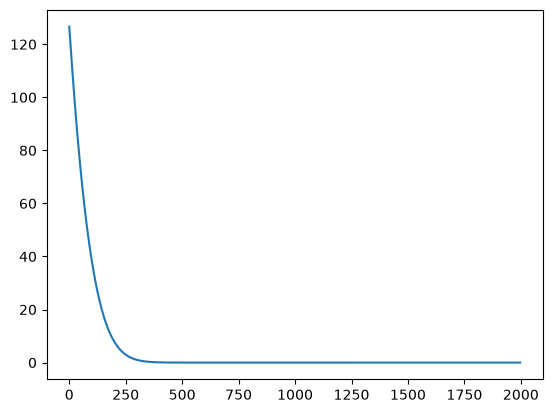

In [ ]:
for t in range(1,1000):
    #Forwared propagation
    y_pred=w*x
    
    #MSE
    loss=torch.mean((y_pred-y)**2)
    
    # Backpropagation
    loss.backward()
    
    #Gradient
    grad=w.grad.item()
    
    # First moment
    m=m*beta1+(1-beta1)*grad
    
    # Second moment
    v=v*beta2+(1-beta2)*grad**2
    
    #Bias correction
    m_hat=m/(1-(beta1)**t)
    v_hat=v/(1-(beta2)**t)
    
    with torch.no_grad():
        w-=lr*m_hat/(torch.sqrt(torch.tensor(v_hat))+epsilon)
        
    w.grad.zero_()
    loss_history.append(loss.item())
    print(f"For {t} loss is {loss}")
plt.plot(loss_history)
plt.show()

RMS(Root Mean Square)Prop

In [40]:
rmse_history = []
for t in range(1, 1000):

    # Forward propagation
    y_pred = w * x

    # MSE
    mse = torch.mean((y_pred - y) ** 2)

    # RMSE
    rmse = torch.sqrt(mse)

    # Backpropagation
    mse.backward()

    # Gradient
    grad = w.grad.item()

    # RMSProp
    v = beta1* v + (1 - beta1) * grad ** 2

    # Weight update
    with torch.no_grad():
        w -= lr * grad / (
            torch.sqrt(torch.tensor(v)) + epsilon
        )

    # Clear gradient
    w.grad.zero_()

    # Store RMSE
    rmse_history.append(rmse.item())

    if t % 100 == 0:
        print(
            f"Iteration: {t}, "
            f"RMSE: {rmse.item():.6f}, "
            f"Weight: {w.item():.6f}"
        )

Iteration: 100, RMSE: 0.000000, Weight: 2.000000
Iteration: 200, RMSE: 0.000000, Weight: 2.000000
Iteration: 300, RMSE: 0.000000, Weight: 2.000000
Iteration: 400, RMSE: 0.000000, Weight: 2.000000
Iteration: 500, RMSE: 0.000000, Weight: 2.000000
Iteration: 600, RMSE: 0.000000, Weight: 2.000000
Iteration: 700, RMSE: 0.000000, Weight: 2.000000
Iteration: 800, RMSE: 0.000000, Weight: 2.000000
Iteration: 900, RMSE: 0.000000, Weight: 2.000000


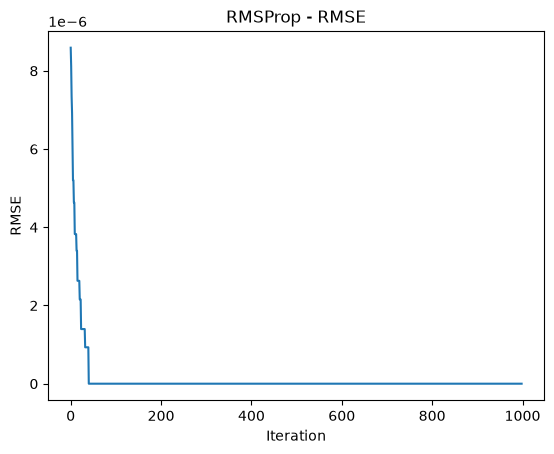

In [41]:
plt.plot(rmse_history)
plt.xlabel("Iteration")
plt.ylabel("RMSE")
plt.title("RMSProp - RMSE")
plt.show()